# **Day 7: Linear Algebra for Machine Learning**
*Module 1 - Foundations and Tools*

Linear algebra is the language of ML. A dataset is a **matrix**, a sample is a **vector**, a linear model is a **matrix-vector product**, PCA is an **eigen-decomposition**, and neural networks are chains of **matrix multiplications**.

> Linear algebra is the maths of vectors and matrices. A data set is a matrix (samples x features), a model's weights are a vector, and a prediction is a matrix multiplication. PCA, regression and neural networks are all built on it.
>
> *Example:* Converting four Sentinel-2 bands into one vegetation score with weights (0, -0.5, 0, 0.5) is a dot product: score = w . x.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(7)

## **1. Vectors**
A sample with $d$ features is a vector $\mathbf{x} \in \mathbb{R}^d$.

| Operation | Formula | ML meaning |
|---|---|---|
| Dot product | $\mathbf{w}\cdot\mathbf{x}=\sum_i w_i x_i$ | Linear model output, similarity |
| L2 norm | $\lVert\mathbf{x}\rVert_2=\sqrt{\sum x_i^2}$ | Length; Euclidean distance; Ridge penalty |
| L1 norm | $\lVert\mathbf{x}\rVert_1=\sum \lvert x_i\rvert$ | Manhattan distance; Lasso penalty |
| Cosine similarity | $\frac{\mathbf{a}\cdot\mathbf{b}}{\lVert\mathbf{a}\rVert\lVert\mathbf{b}\rVert}$ | Similarity independent of magnitude (text, spectra) |

In [2]:
a = np.array([0.05, 0.08, 0.06, 0.40])     # a vegetation spectrum (B, G, R, NIR)
b = np.array([0.03, 0.05, 0.04, 0.25])     # same vegetation in shadow (darker)
c = np.array([0.20, 0.22, 0.25, 0.30])     # bare soil

def cosine(u, v):
    return u @ v / (np.linalg.norm(u) * np.linalg.norm(v))

print(f"Euclidean distance a-b: {np.linalg.norm(a - b):.3f} | a-c: {np.linalg.norm(a - c):.3f}")
print(f"Cosine similarity  a-b: {cosine(a, b):.3f} | a-c: {cosine(a, c):.3f}")
print(f"Spectral angle     a-b: {np.degrees(np.arccos(cosine(a, b))):.1f} deg | a-c: {np.degrees(np.arccos(cosine(a, c))):.1f} deg")
print("L1, L2, Linf norms of a:", np.linalg.norm(a, 1).round(3), np.linalg.norm(a).round(3), np.linalg.norm(a, np.inf))

Euclidean distance a-b: 0.156 | a-c: 0.297
Cosine similarity  a-b: 1.000 | a-c: 0.798
Spectral angle     a-b: 0.6 deg | a-c: 37.1 deg
L1, L2, Linf norms of a: 0.59 0.415 0.4


Euclidean distance says shadowed vegetation is far from sunlit vegetation. Cosine similarity (the **Spectral Angle Mapper**) says they are almost identical. The choice of distance is a modelling decision (Day 30).

## **2. Matrices as Transformations**
A matrix $A$ maps vectors to vectors: $\mathbf{y} = A\mathbf{x}$. Every layer of a neural network does this followed by a non-linearity.

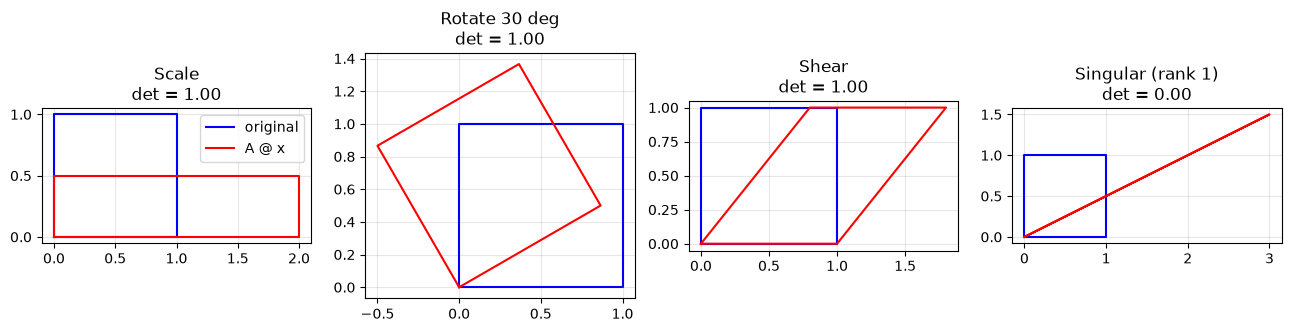

In [3]:
square = np.array([[0, 1, 1, 0, 0], [0, 0, 1, 1, 0]])
transforms = {"Scale": np.array([[2, 0], [0, 0.5]]),
              "Rotate 30 deg": np.array([[np.cos(np.pi / 6), -np.sin(np.pi / 6)], [np.sin(np.pi / 6), np.cos(np.pi / 6)]]),
              "Shear": np.array([[1, 0.8], [0, 1]]),
              "Singular (rank 1)": np.array([[1, 2], [0.5, 1]])}
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, A) in zip(axes, transforms.items()):
    ax.plot(*square, "b-", label="original"); ax.plot(*(A @ square), "r-", label="A @ x")
    ax.set_title(f"{name}\ndet = {np.linalg.det(A):.2f}"); ax.set_aspect("equal"); ax.grid(alpha=0.3)
axes[0].legend(); plt.show()

The **determinant** is the area scaling factor. det = 0 means the matrix squashes space onto a line: information is lost and the matrix has **no inverse**.

### Key matrix facts

In [4]:
X = rng.normal(size=(5, 3))                      # 5 samples, 3 features
print("X shape:", X.shape, "| X.T shape:", X.T.shape)
G = X.T @ X                                       # Gram matrix (3x3), appears in linear regression
print("X^T X is symmetric:", np.allclose(G, G.T))
print("Rank of X:", np.linalg.matrix_rank(X))
X_dup = np.c_[X, X[:, 0] * 2]                    # 4th feature = 2 x first feature
print("Rank with a duplicated feature:", np.linalg.matrix_rank(X_dup), "(of 4 columns) -> X^T X is singular")
print("(AB)^T = B^T A^T:", np.allclose((X @ G).T, G.T @ X.T))

X shape: (5, 3) | X.T shape: (3, 5)
X^T X is symmetric: True
Rank of X: 3
Rank with a duplicated feature: 3 (of 4 columns) -> X^T X is singular
(AB)^T = B^T A^T: True


## **3. Linear Systems and Least Squares**
Linear regression wants weights $\mathbf{w}$ such that $X\mathbf{w} \approx \mathbf{y}$. With more samples than features there is no exact solution, so we minimise $\lVert X\mathbf{w}-\mathbf{y}\rVert^2$. Setting the gradient to zero gives the **normal equations**:

$$X^\top X\,\mathbf{w} = X^\top \mathbf{y} \quad\Rightarrow\quad \mathbf{w} = (X^\top X)^{-1}X^\top\mathbf{y}$$

In [5]:
n = 200
X = np.c_[np.ones(n), rng.uniform(0, 1, (n, 2))]   # bias column + 2 features
w_true = np.array([1.0, 3.0, -2.0])
y = X @ w_true + rng.normal(0, 0.1, n)

w_normal = np.linalg.inv(X.T @ X) @ X.T @ y          # textbook formula (avoid in practice)
w_solve = np.linalg.solve(X.T @ X, X.T @ y)          # better: solve, don't invert
w_lstsq, *_ = np.linalg.lstsq(X, y, rcond=None)      # best: QR/SVD-based
print("True    :", w_true)
print("inv     :", w_normal.round(3))
print("solve   :", w_solve.round(3))
print("lstsq   :", w_lstsq.round(3))

True    : [ 1.  3. -2.]
inv     : [ 0.995  3.003 -2.036]
solve   : [ 0.995  3.003 -2.036]
lstsq   : [ 0.995  3.003 -2.036]


**Geometric view:** $X\hat{\mathbf{w}}$ is the **orthogonal projection** of $\mathbf{y}$ onto the column space of $X$, so the residual is perpendicular to every column: $X^\top(\mathbf{y}-X\hat{\mathbf{w}}) = \mathbf{0}$.

In [6]:
residual = y - X @ w_lstsq
print("X^T residual (should be ~0):", (X.T @ residual).round(10))

X^T residual (should be ~0): [-0. -0. -0.]


## **4. Eigenvalues and Eigenvectors**
An eigenvector $\mathbf{v}$ of $A$ only gets **stretched**, not rotated: $A\mathbf{v} = \lambda\mathbf{v}$.
For a **covariance matrix**, eigenvectors are the directions of maximum spread and eigenvalues are the variances along them. This is **PCA** (Day 49).

Eigenvalues (variances along principal axes): [4.631 0.269]
Share of variance on the first axis: 94.5%


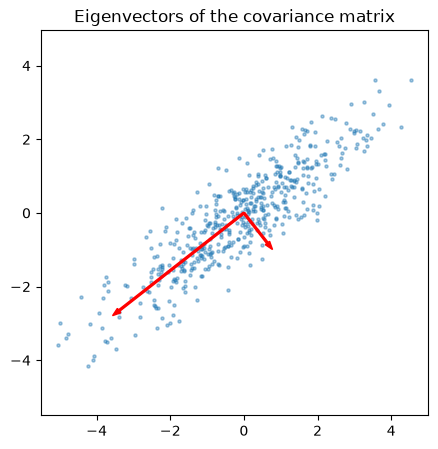

In [7]:
cov_true = np.array([[3.0, 2.2], [2.2, 2.0]])
D = rng.multivariate_normal([0, 0], cov_true, 500)
C = np.cov(D.T)
eigvals, eigvecs = np.linalg.eigh(C)            # eigh: for symmetric matrices (sorted ascending)
order = eigvals.argsort()[::-1]; eigvals, eigvecs = eigvals[order], eigvecs[:, order]
print("Eigenvalues (variances along principal axes):", eigvals.round(3))
print(f"Share of variance on the first axis: {eigvals[0] / eigvals.sum():.1%}")

plt.figure(figsize=(5, 5))
plt.scatter(*D.T, s=5, alpha=0.4)
for val, vec in zip(eigvals, eigvecs.T):
    plt.arrow(0, 0, *(vec * 2 * np.sqrt(val)), width=0.05, color="r")
plt.axis("equal"); plt.title("Eigenvectors of the covariance matrix"); plt.show()

## **5. Singular Value Decomposition (SVD)**
**Every** matrix can be factorised as $X = U\Sigma V^\top$ ($U$, $V$ orthogonal, $\Sigma$ diagonal with singular values $\sigma_1 \ge \sigma_2 \ge \dots \ge 0$). Keeping only the top $k$ singular values gives the **best rank-$k$ approximation** (Eckart-Young theorem). Uses: PCA, compression, denoising, recommender systems (Day 52), latent semantic analysis.

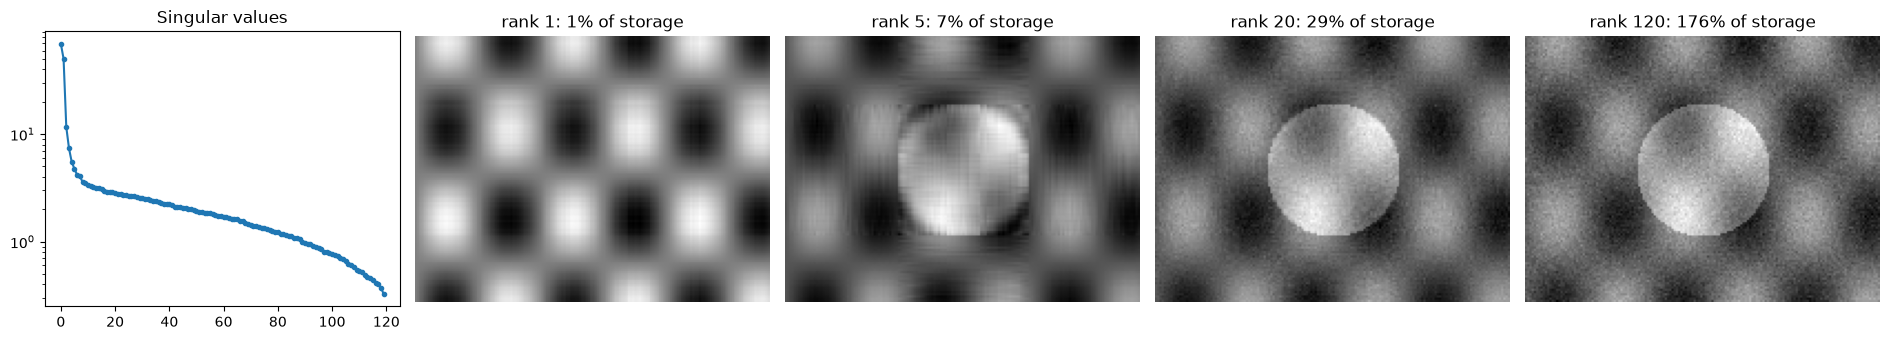

In [8]:
yy, xx = np.mgrid[0:120, 0:160]
image = (np.sin(xx / 9) * np.cos(yy / 13) + ((xx - 80) ** 2 + (yy - 60) ** 2 < 900) + rng.normal(0, 0.15, xx.shape))
U, s, Vt = np.linalg.svd(image, full_matrices=False)

fig, axes = plt.subplots(1, 5, figsize=(19, 3.5))
axes[0].semilogy(s, "o-", ms=3); axes[0].set_title("Singular values")
for ax, k in zip(axes[1:], [1, 5, 20, 120]):
    approx = U[:, :k] @ np.diag(s[:k]) @ Vt[:k]
    stored = k * (U.shape[0] + Vt.shape[1] + 1)
    ax.imshow(approx, cmap="gray"); ax.axis("off")
    ax.set_title(f"rank {k}: {stored / image.size:.0%} of storage")
plt.tight_layout(); plt.show()

A rank-20 approximation keeps the structure and removes much of the noise, using about a third of the storage.

# **Part 2: Going Deeper - Numerical Stability**

### Condition number
The **condition number** $\kappa(A)=\sigma_{\max}/\sigma_{\min}$ measures how much errors in the input are amplified. Highly correlated features make $X^\top X$ **ill-conditioned**, and regression coefficients explode. Regularisation (Ridge, Day 24) fixes this by adding $\lambda I$.

In [9]:
x1 = rng.normal(size=100)
for eps in [1.0, 0.1, 0.01, 0.001]:
    x2 = x1 + eps * rng.normal(size=100)               # x2 ~ x1 when eps is small
    Xc = np.c_[x1, x2]
    y_c = x1 + x2 + rng.normal(0, 0.1, 100)
    w = np.linalg.lstsq(Xc, y_c, rcond=None)[0]
    w_ridge = np.linalg.solve(Xc.T @ Xc + 1.0 * np.eye(2), Xc.T @ y_c)
    print(f"eps={eps:<6} cond(X^T X)={np.linalg.cond(Xc.T @ Xc):>12.1f}  OLS w={w.round(2)}  Ridge w={w_ridge.round(2)}")

eps=1.0    cond(X^T X)=         4.3  OLS w=[1.02 1.  ]  Ridge w=[1.01 0.99]
eps=0.1    cond(X^T X)=       348.5  OLS w=[1.02 0.97]  Ridge w=[1.   0.98]
eps=0.01   cond(X^T X)=     26159.2  OLS w=[1.33 0.66]  Ridge w=[0.99 0.99]
eps=0.001  cond(X^T X)=   3823295.6  OLS w=[-31.57  33.58]  Ridge w=[0.99 1.  ]


True weights are [1, 1]. As the features become nearly identical, OLS weights become wild while Ridge stays stable.

### Positive (semi-)definite matrices
A symmetric matrix $A$ is **positive definite** if $\mathbf{x}^\top A\mathbf{x} > 0$ for all $\mathbf{x}\neq 0$ (all eigenvalues > 0). Covariance matrices and kernel matrices (SVM, Gaussian processes) are PSD. The **Cholesky** factorisation $A = LL^\top$ exists only for PD matrices and is used to sample correlated random variables.

In [10]:
L = np.linalg.cholesky(cov_true)
samples = rng.normal(size=(10000, 2)) @ L.T
print("Target covariance:\n", cov_true, "\nSample covariance:\n", np.cov(samples.T).round(2))
print("Eigenvalues of a covariance matrix are >= 0:", np.linalg.eigvalsh(np.cov(D.T)).round(3))

Target covariance:
 [[3.  2.2]
 [2.2 2. ]] 
Sample covariance:
 [[3.   2.22]
 [2.22 2.02]]
Eigenvalues of a covariance matrix are >= 0: [0.269 4.631]


## **Practice Problems**
1. Compute the cosine similarity between all pairs of rows of a random 4x6 matrix in one line.
2. Show that the eigenvectors of a symmetric matrix are orthogonal ($V^\top V = I$).
3. Use the SVD to compute the pseudo-inverse $X^+ = V\Sigma^{-1}U^\top$ and compare it with `np.linalg.pinv`.
4. *(Advanced)* Show that the squared singular values of the centred data matrix divided by $(n-1)$ equal the eigenvalues of its covariance matrix.

In [11]:
# Solution 1
R = rng.normal(size=(4, 6)); Rn = R / np.linalg.norm(R, axis=1, keepdims=True)
print((Rn @ Rn.T).round(2))
# Solution 2
print(np.allclose(eigvecs.T @ eigvecs, np.eye(2)))
# Solution 3
U3, s3, Vt3 = np.linalg.svd(X, full_matrices=False)
print(np.allclose(Vt3.T @ np.diag(1 / s3) @ U3.T, np.linalg.pinv(X)))
# Solution 4
Dc = D - D.mean(0)
print(np.allclose(np.sort(np.linalg.svd(Dc, compute_uv=False) ** 2 / (len(D) - 1)), np.sort(np.linalg.eigvalsh(np.cov(D.T)))))

[[ 1.   -0.25  0.48  0.14]
 [-0.25  1.    0.09  0.69]
 [ 0.48  0.09  1.    0.52]
 [ 0.14  0.69  0.52  1.  ]]
True
True
True


## **Key References**
- Strang, G. (2019). *Linear Algebra and Learning from Data*. Wellesley-Cambridge Press.
- Deisenroth, M. P., Faisal, A. A., & Ong, C. S. (2020). *Mathematics for Machine Learning*. Cambridge University Press (free online).
- Eckart, C., & Young, G. (1936). The approximation of one matrix by another of lower rank. *Psychometrika*, 1(3), 211-218.
- Golub, G. H., & Van Loan, C. F. (2013). *Matrix Computations* (4th ed.). Johns Hopkins University Press.